# Toy problem: RV-SDDP versus Cyclic SDDP

This notebook reproduces the figures of the toy problem presented in the accompanying paper. It loads the precomputed numerical results from the `results_toy/` directory and generates the corresponding plots.

To run the RV-SDDP and Cyclic SDDP algorithms and reproduce some of the numerical results from scratch, see the notebook `notebook_toy.ipynb`.

In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using CSV
using DataFrames
using Statistics
using Distributions
using LaTeXStrings
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

In [2]:
folder_list = Dict("RV-SDDP" => "shift_update_random_forward_0_parallel_1", "Cyclic SDDP" => "no_shift_0_parallel_1")

Dict{String, String} with 2 entries:
  "Cyclic SDDP" => "no_shift_0_parallel_1"
  "RV-SDDP"     => "shift_update_random_forward_0_parallel_1"

## Comparison of value function approximations obtained by RV-SDDP and cyclic SDDP after 100 iterations.

In [8]:
period = 1
discount_factor=0.99
graph=RVSDDP.InfiniteLinearGraph(period);
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    @variable(subproblem, 0 <= volume <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation >= 0
        hydro_generation >= 0
        hydro_spill >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 90.0]
    P = [1 / length(Ω) for _ in Ω]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            volume.out == volume.in - hydro_generation - hydro_spill + inflow
            hydro_generation <= 100
            thermal_generation <= 30
            deficit + hydro_generation + thermal_generation == 60
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 50*hydro_spill + 50 * deficit+ 2*thermal_generation)
    return subproblem
end
iter_max = 100

100

In [9]:
model_no_shift = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

folder = "results_toy/no_shift_0_parallel_1/$(discount_factor)/seed_1_iter_$(iter_max)" 

RVSDDP._add_cuts_iter(model_no_shift, iter_max, folder);

model_RVSDDP = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

folder = "results_toy/shift_update_random_forward_0_parallel_1/$(discount_factor)/seed_1_iter_$(iter_max)" 

RVSDDP._add_cuts_iter(model_RVSDDP, iter_max, folder);

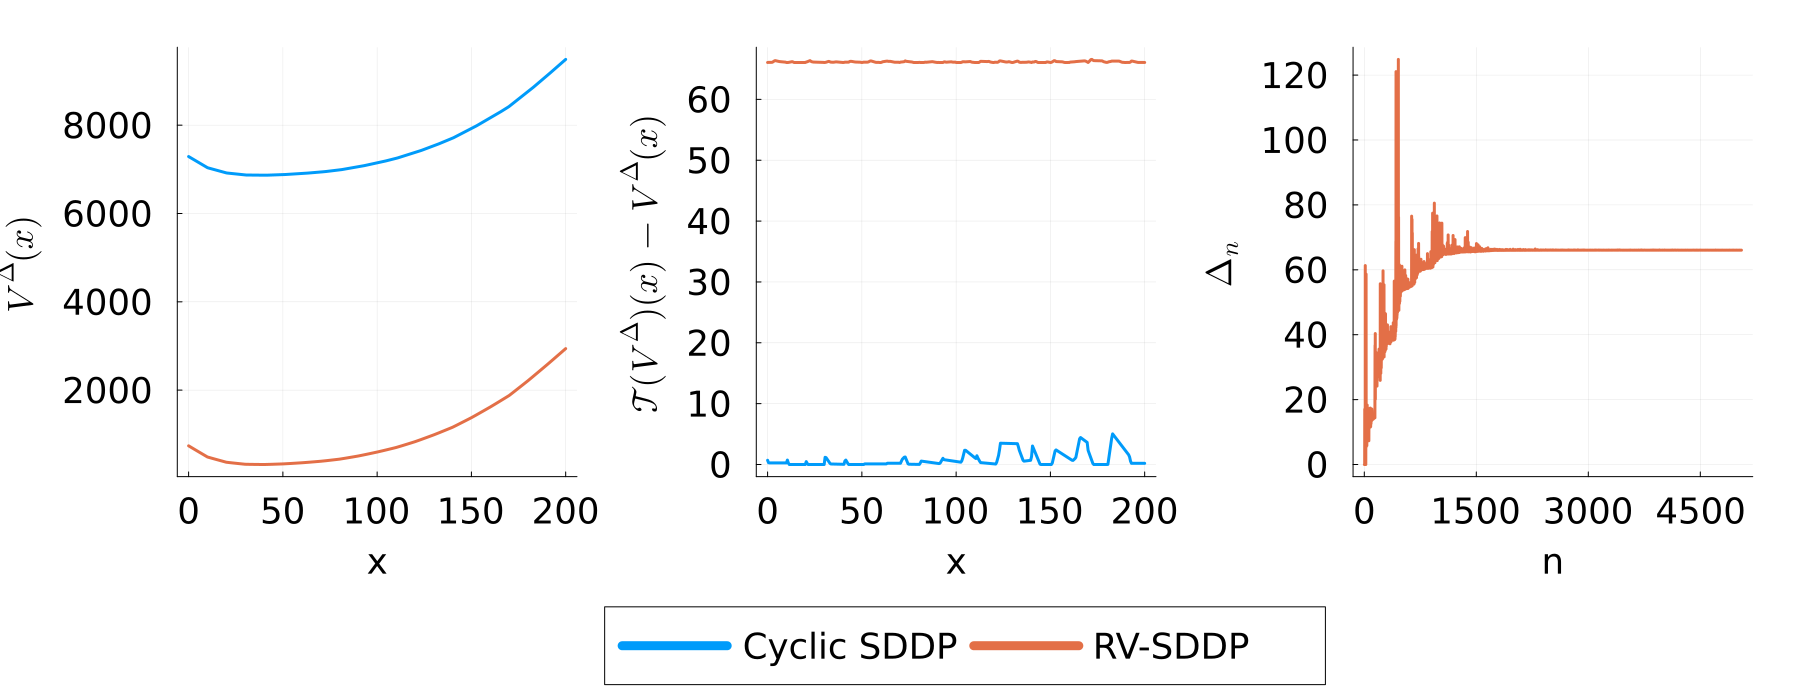

In [10]:
ind = 0:0.5:200
fontsize = 24
V_no_shift = [RVSDDP.compute_V(model_no_shift[1].value_function, Dict(:volume=>1.0*i)) for i in ind]
V_RVSDDP = [RVSDDP.compute_V(model_RVSDDP[1].value_function, Dict(:volume=>1.0*i)) for i in ind]

TV_no_shift = [RVSDDP.compute_TV(model_no_shift[1], Dict(:volume=>1.0*i)) for i in ind]
TV_RVSDDP = [RVSDDP.compute_TV(model_RVSDDP[1], Dict(:volume=>1.0*i)) for i in ind]

p1 = plot(
    ind,
    V_no_shift,
    label = false,
    xlabel = "x",
    ylabel = L"V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p1, ind, V_RVSDDP, label = false, linewidth = 3)

p2 = plot(
    ind,
    TV_no_shift - V_no_shift,
    label = false,
    xlabel = "x",
    ylabel = L"\mathcal{T}(V^\Delta)(x) - V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p2, ind, TV_RVSDDP - V_RVSDDP, label = false, linewidth = 3)

p3=plot(label = false, xlabel="n", ylabel =L"\Delta_n",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)

plot!(p3, [cut.shift[1][1] for cut in model_RVSDDP[1].value_function.cut_V], xticks = [0, 1500,3000,4500],label=false, linewidth=3, color = 2)

pleg = plot(
    [NaN], [NaN],
    label = "Cyclic SDDP",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :bottom,
    legend_columns = 2,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
)
plot!(
    pleg,
    [NaN], [NaN],
    label = "RV-SDDP",
    linewidth = 3,
    color = 2,
)

plot(
    p1,
    p2,
    p3,
    pleg,
    layout = @layout([a b c; d{0.2h}]),
    size = (1800, 700),
)
# savefig("results_toy/vf_and_TV-V.pdf")

## Evolution of the policy cost and number of active cuts for RV-SDDP and cyclic SDDP across iterations.

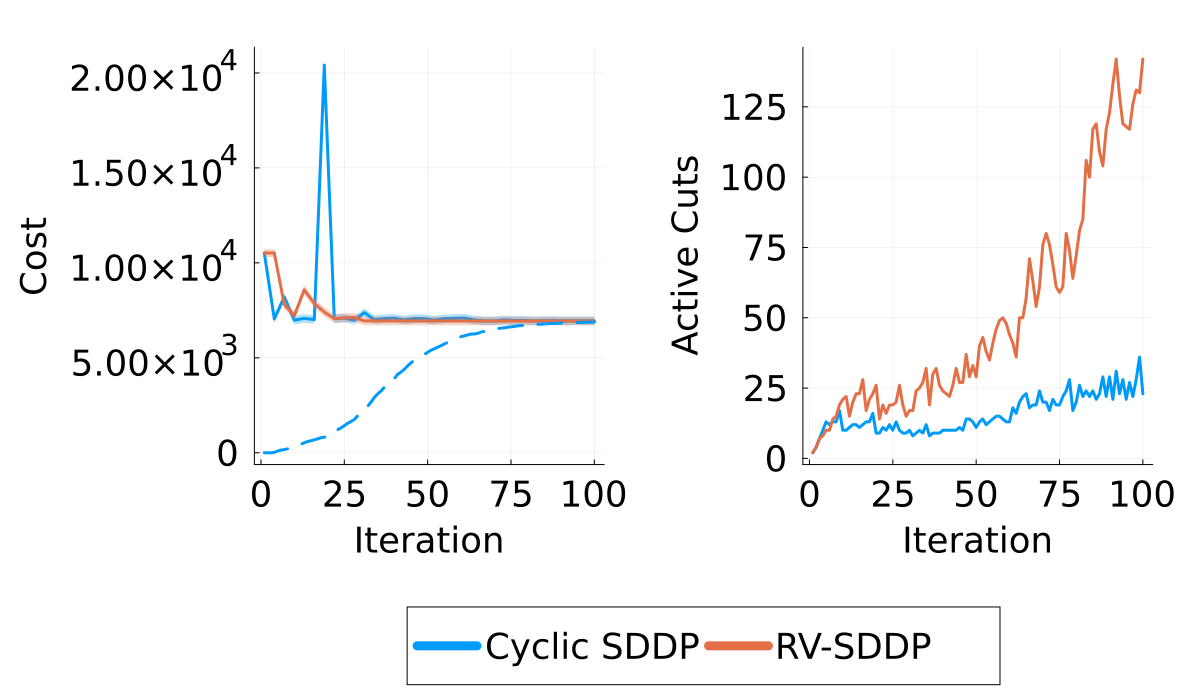

In [16]:
results = Dict()
seed = 1
iter_max = 100
parallel = 1
iter_list_oos = 1:3:100
discount_factor=0.99
N=1000
TimeHorizon = Int(ceil(log(0.001)/(log(discount_factor))))
iter_list_value = 1:1:100

for (label,folder) in folder_list
      folder = "results_toy/$(folder)/$(discount_factor)/seed_$(seed)_iter_$(iter_max)"
      df_deltas = CSV.read(joinpath(folder, "deltas.csv"), DataFrame)
      deltas = [df_deltas[df_deltas[:, :node] .== t, :delta] for t in 1:period]
      oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_horizon_$(iter)_$(TimeHorizon)_$N.csv"), DataFrame)[1:N, :oos_horizon] for iter in iter_list_oos]
      active_cuts_df = [sum(CSV.read(joinpath("$(folder)/active_cuts", "iteration_$(iter).csv"), DataFrame)[1:period, :num_active_cuts]) for iter in iter_list_value]
      approx_value_df = CSV.read(joinpath("$(folder)/approx_values.csv"), DataFrame).approx_value[iter_list_value]
      results[label] = (deltas, oos_df, active_cuts_df, approx_value_df)
end


results_mean = Dict()
for label in keys(folder_list)
      all_oos_df = [results[label][2][i]  for (i, _) in enumerate(iter_list_oos)]

      oos_matrix = [hcat(all_oos_df[i]...) for i in 1:length(all_oos_df)]  # length(iter_list_oos) x (N * length(seed_list)) matrix

      oos_mean = [mean(oos_matrix[i]) for i in 1:length(oos_matrix)]
      oos_std = [std(oos_matrix[i]) for i in 1:length(oos_matrix)]

      results_mean[label] = (oos_mean, oos_std)
end

tcrit = quantile(TDist(N-1), 0.975)

fontsize = 24
p1=plot(label = false, xlabel="Iteration", ylabel ="Cost",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)
p2=plot(label = false, xlabel="Iteration", ylabel ="Active Cuts",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)
p3=plot(label = false, xlabel="Iteration", ylabel =L"\Delta_n",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)

color=1
for (label, _) in folder_list
      oos_mean = results_mean[label][1]
      oos_mean_up = results_mean[label][1] + tcrit * results_mean[label][2] / sqrt(N)
      oos_mean_down = results_mean[label][1] - tcrit * results_mean[label][2] / sqrt(N)
      plot!(p1, iter_list_oos, oos_mean,label=false, ribbon=(oos_mean - oos_mean_down, oos_mean_up - oos_mean), linewidth=3, fillalpha=0.3, color = color)

      active_mean = results[label][3]
      plot!(p2, iter_list_value, active_mean, label=false, linewidth=3, fillalpha=0.0, color = color)
      color += 1
end
plot!(p1, iter_list_value, results["Cyclic SDDP"][4], label=false, linewidth=3, linestyle=:dash, color = 1)

pleg = plot(
    [NaN], [NaN],
    label = "Cyclic SDDP",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :bottom,
    legend_columns = 2,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
)
plot!(
    pleg,
    [NaN], [NaN],
    label = "RV-SDDP",
    linewidth = 3,
    color = 2,
)

plot(
    p1,
    p2,
    pleg,
    layout = @layout([a b; d{0.2h}]),
    size = (1200, 700),
)
# savefig("results_toy/cuts_active_toy_$discount_factor.pdf")

## Value function approximations produced by cyclic SDDP at different iterations.

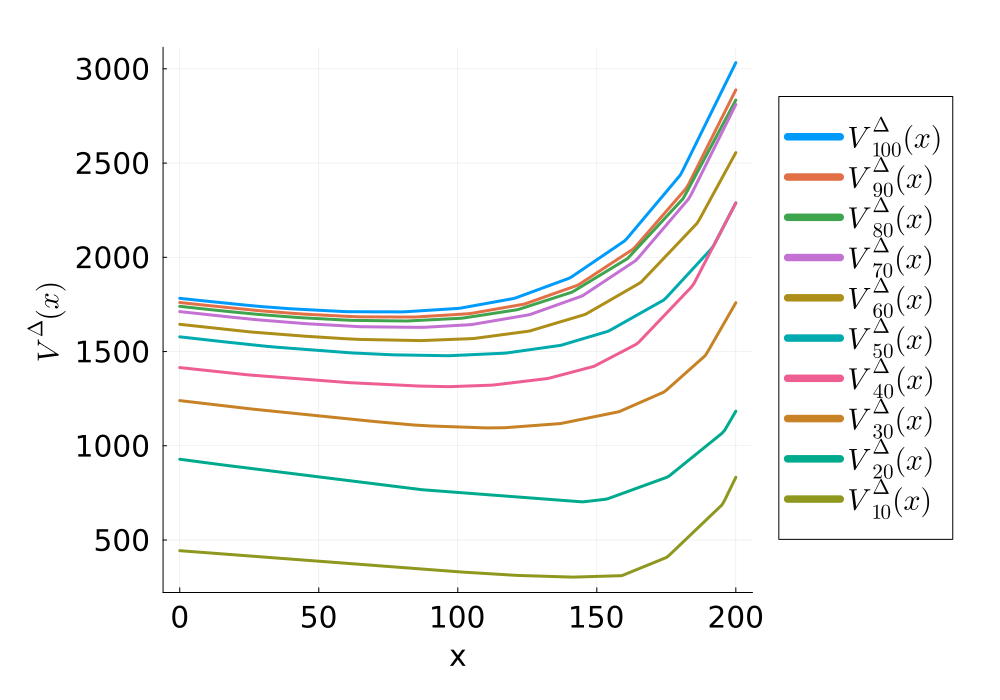

In [19]:
model_no_shift = [RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    ) for iter in 10:10:iter_max]

folder = "results_toy/no_shift_0_parallel_1/$(discount_factor)/seed_1_iter_$(iter_max)" 

for (i, iter) in enumerate(10:10:iter_max)
    RVSDDP._add_cuts_iter(model_no_shift[i], iter, folder);
end

ind = 0:1:200

fontsize = 20

p=plot(xlabel="x", ylabel = L"V^\Delta(x)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 700), margin=10Plots.mm, legend=:outerright)
for k in 1:10
    i = 10-k+1
    iter = i*10
    RVSDDP._add_cuts_iter(model_no_shift[i], iter, folder)
    V_no_shift = [RVSDDP.compute_V(model_no_shift[i][1].value_function, Dict(Symbol("volume[1]")=>1.0*j)) for j in ind]
    plot!(p, ind, V_no_shift, label = latexstring("V^\\Delta_{$iter}(x)"), linewidth = 3)
end
p

# savefig("results_toy/vf_iter_toy.pdf")